In [22]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Iris 데이터셋 로드
iris = load_iris()
X, y = iris.data, iris.target

# 2. Pipeline 구성 (스케일링 + 모델 정의)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42))
])

# 3. 측정할 평가 지표 정의 (다중 클래스이므로 macro 평균 사용)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# 4. 교차 검증 수행 (5-Fold CV)
results = cross_validate(pipeline, X, y, cv=5, scoring=scoring)
# print(results)
# 5. 지표별 Mean 및 Std 출력
metrics_map = {
    'Accuracy': 'test_accuracy',
    'Precision': 'test_precision_macro',
    'Recall': 'test_recall_macro',
    'F1-Score': 'test_f1_macro'
}

print("=== 5-Fold Cross Validation Results ===")
for metric_name, score_key in metrics_map.items():
    scores = results[score_key]
    mean = np.mean(scores)
    std = np.std(scores)
    print(f"{metric_name:10s} | Mean: {mean:.4f} | Std: {std:.4f}")

=== 5-Fold Cross Validation Results ===
Accuracy   | Mean: 0.9600 | Std: 0.0389
Precision  | Mean: 0.9633 | Std: 0.0369
Recall     | Mean: 0.9600 | Std: 0.0389
F1-Score   | Mean: 0.9598 | Std: 0.0390


In [17]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Iris 데이터셋 로드
iris = load_iris()
X, y = iris.data, iris.target

# 2. Pipeline 구성 (스케일링 + 모델 정의)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42))
])

# 3. 측정할 평가 지표 정의 (다중 클래스이므로 macro 평균 사용)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# 4. 교차 검증 수행 (5-Fold CV)
results = cross_validate(pipeline, X, y, cv=5, scoring=scoring)

# 5. 지표별 Mean 및 Std 출력
metrics_map = {
    'Accuracy': 'test_accuracy',
    'Precision': 'test_precision_macro',
    'Recall': 'test_recall_macro',
    'F1-Score': 'test_f1_macro'
}

print("=== 5-Fold Cross Validation Results ===")
for metric_name, score_key in metrics_map.items():
    scores = results[score_key]
    mean = np.mean(scores)
    std = np.std(scores)
    print(f"{metric_name:10s} | Mean: {mean:.4f} | Std: {std:.4f}")

=== 5-Fold Cross Validation Results ===
Accuracy   | Mean: 0.9600 | Std: 0.0389
Precision  | Mean: 0.9633 | Std: 0.0369
Recall     | Mean: 0.9600 | Std: 0.0389
F1-Score   | Mean: 0.9598 | Std: 0.0390


In [18]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. 데이터셋 로드
iris = load_iris()
X, y = iris.data, iris.target

# 2. Pipeline 구성
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42))
])

# 3. 평가 지표 목록 (다중 클래스 평가용 macro 지표 사용)
metrics = {
    'Accuracy': 'accuracy',
    'Precision': 'precision_macro',
    'Recall': 'recall_macro',
    'F1-Score': 'f1_macro'
}

print("=== cross_val_score 개별 실행 결과 ===")
# 4. 각 지표마다 cross_val_score를 개별적으로 호출
for metric_name, scoring_param in metrics.items():
    scores = cross_val_score(pipeline, X, y, cv=5, scoring=scoring_param)
    
    mean = np.mean(scores)
    std = np.std(scores)
    
    print(f"{metric_name:10s} | Mean: {mean:.4f} | Std: {std:.4f}")

=== cross_val_score 개별 실행 결과 ===
Accuracy   | Mean: 0.9600 | Std: 0.0389
Precision  | Mean: 0.9633 | Std: 0.0369
Recall     | Mean: 0.9600 | Std: 0.0389
F1-Score   | Mean: 0.9598 | Std: 0.0390


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def run_comprehensive_eda(df: pd.DataFrame):
    """
    데이터셋 입력 시 필수 요약 통계 출력 및 핵심 시각화를 실행하는 EDA 자동화 함수
    """
    print("=" * 60)
    print("1. 데이터 기본 구조 및 결측치 요약")
    print("=" * 60)
    print(f"- 데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
    print(f"- 중복 행 수: {df.duplicated().sum()}개")
    
    # 타입, 결측치, 고유값 통합 데이터프레임 생성
    info_df = pd.DataFrame({
        'Dtype': df.dtypes,
        'Missing_Count': df.isnull().sum(),
        'Missing_Ratio(%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique_Values': df.nunique()
    })
    print("\n[변수별 품질 요약]")
    print(info_df)

    # 변수 타입별 분류
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    print("\n" + "=" * 60)
    print("2. 수치형 및 범주형 변수 기술 통계량")
    print("=" * 60)
    if num_cols:
        print("\n[수치형 변수 요약]")
        print(df[num_cols].describe().T[['mean', 'std', 'min', '50%', 'max']])
    if cat_cols:
        print("\n[범주형 변수 요약]")
        print(df[cat_cols].describe().T[['count', 'unique', 'top', 'freq']])

    # 3. 시각화 단계
    # 3-1. 수치형 변수 분포(KDE) 및 이상치(Boxplot)
    if num_cols:
        fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 3.5 * len(num_cols)))
        if len(num_cols) == 1:
            axes = np.array([axes])

        for i, col in enumerate(num_cols):
            # 히스토그램 & 밀도 그래프
            sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
            axes[i, 0].set_title(f'{col} - Distribution (Skewness: {df[col].skew():.2f})')
            
            # 박스플롯
            sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
            axes[i, 1].set_title(f'{col} - Outliers (Boxplot)')

        plt.tight_layout()
        plt.show()

    # 3-2. 범주형 변수 클래스 분포(Countplot)
    if cat_cols:
        cols_per_row = 2
        rows = (len(cat_cols) + cols_per_row - 1) // cols_per_row
        fig, axes = plt.subplots(rows, cols_per_row, figsize=(12, 3.5 * rows))
        axes = np.array(axes).flatten() if len(cat_cols) > 1 else np.array([axes])

        for i, col in enumerate(cat_cols):
            sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
            axes[i].set_title(f'{col} - Class Frequencies')
            axes[i].tick_params(axis='x', rotation=30)

        for j in range(len(cat_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    # 3-3. 수치형 피처 간 선형 상관계수 히트맵
    if len(num_cols) > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
        plt.title('Numerical Feature Correlation Heatmap')
        plt.show()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def run_comprehensive_eda(df: pd.DataFrame):
    """
    데이터셋 입력 시 필수 요약 통계 출력 및 핵심 시각화를 실행하는 EDA 자동화 함수
    """
    print("=" * 60)
    print("1. 데이터 기본 구조 및 결측치 요약")
    print("=" * 60)
    print(f"- 데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
    print(f"- 중복 행 수: {df.duplicated().sum()}개")
    
    # 타입, 결측치, 고유값 통합 데이터프레임 생성
    info_df = pd.DataFrame({
        'Dtype': df.dtypes,
        'Missing_Count': df.isnull().sum(),
        'Missing_Ratio(%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique_Values': df.nunique()
    })
    print("\n[변수별 품질 요약]")
    print(info_df)

    # 변수 타입별 분류 (Pandas 최신 규격 반영: 'string' 추가)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'string', 'category', 'bool']).columns.tolist()

    print("\n" + "=" * 60)
    print("2. 수치형 및 범주형 변수 기술 통계량")
    print("=" * 60)
    if num_cols:
        print("\n[수치형 변수 요약]")
        print(df[num_cols].describe().T[['mean', 'std', 'min', '50%', 'max']])
    if cat_cols:
        print("\n[범주형 변수 요약]")
        print(df[cat_cols].describe().T[['count', 'unique', 'top', 'freq']])

    # 3. 시각화 단계
    # 3-1. 수치형 변수 분포(KDE) 및 이상치(Boxplot)
    if num_cols:
        fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 3.5 * len(num_cols)))
        if len(num_cols) == 1:
            axes = np.array([axes])

        for i, col in enumerate(num_cols):
            # 히스토그램 & 밀도 그래프
            sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
            axes[i, 0].set_title(f'{col} - Distribution (Skewness: {df[col].skew():.2f})')
            
            # 박스플롯
            sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
            axes[i, 1].set_title(f'{col} - Outliers (Boxplot)')

        plt.tight_layout()
        plt.show()

    # 3-2. 범주형 변수 클래스 분포(Countplot)
    if cat_cols:
        cols_per_row = 2
        rows = (len(cat_cols) + cols_per_row - 1) // cols_per_row
        fig, axes = plt.subplots(rows, cols_per_row, figsize=(12, 3.5 * rows))
        
        # 축 배열 안전하게 1차원 평탄화
        axes = np.atleast_1d(axes).flatten()

        for i, col in enumerate(cat_cols):
            # hue 속성 추가하여 팔레트 경고 방지
            sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue=col, legend=False)
            axes[i].set_title(f'{col} - Class Frequencies')
            axes[i].tick_params(axis='x', rotation=30)

        # 사용하지 않는 축 삭제
        for j in range(len(cat_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    # 3-3. 수치형 피처 간 선형 상관계수 히트맵
    if len(num_cols) > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
        plt.title('Numerical Feature Correlation Heatmap')
        plt.show()

1. 데이터 기본 구조 및 결측치 요약
- 데이터 크기: 900행, 8열
- 중복 행 수: 0개

[변수별 품질 요약]
                   Dtype  Missing_Count  Missing_Ratio(%)  Unique_Values
Area               int64              0               0.0            900
MajorAxisLength  float64              0               0.0            900
MinorAxisLength  float64              0               0.0            900
Eccentricity     float64              0               0.0            900
ConvexArea         int64              0               0.0            896
Extent           float64              0               0.0            900
Perimeter        float64              0               0.0            900
Class                str              0               0.0              2

2. 수치형 및 범주형 변수 기술 통계량

[수치형 변수 요약]
                         mean           std           min           50%  \
Area             87804.127778  39002.111390  25387.000000  78902.000000   
MajorAxisLength    430.929950    116.035121    225.629541    407.803951   
MinorAxisLengt

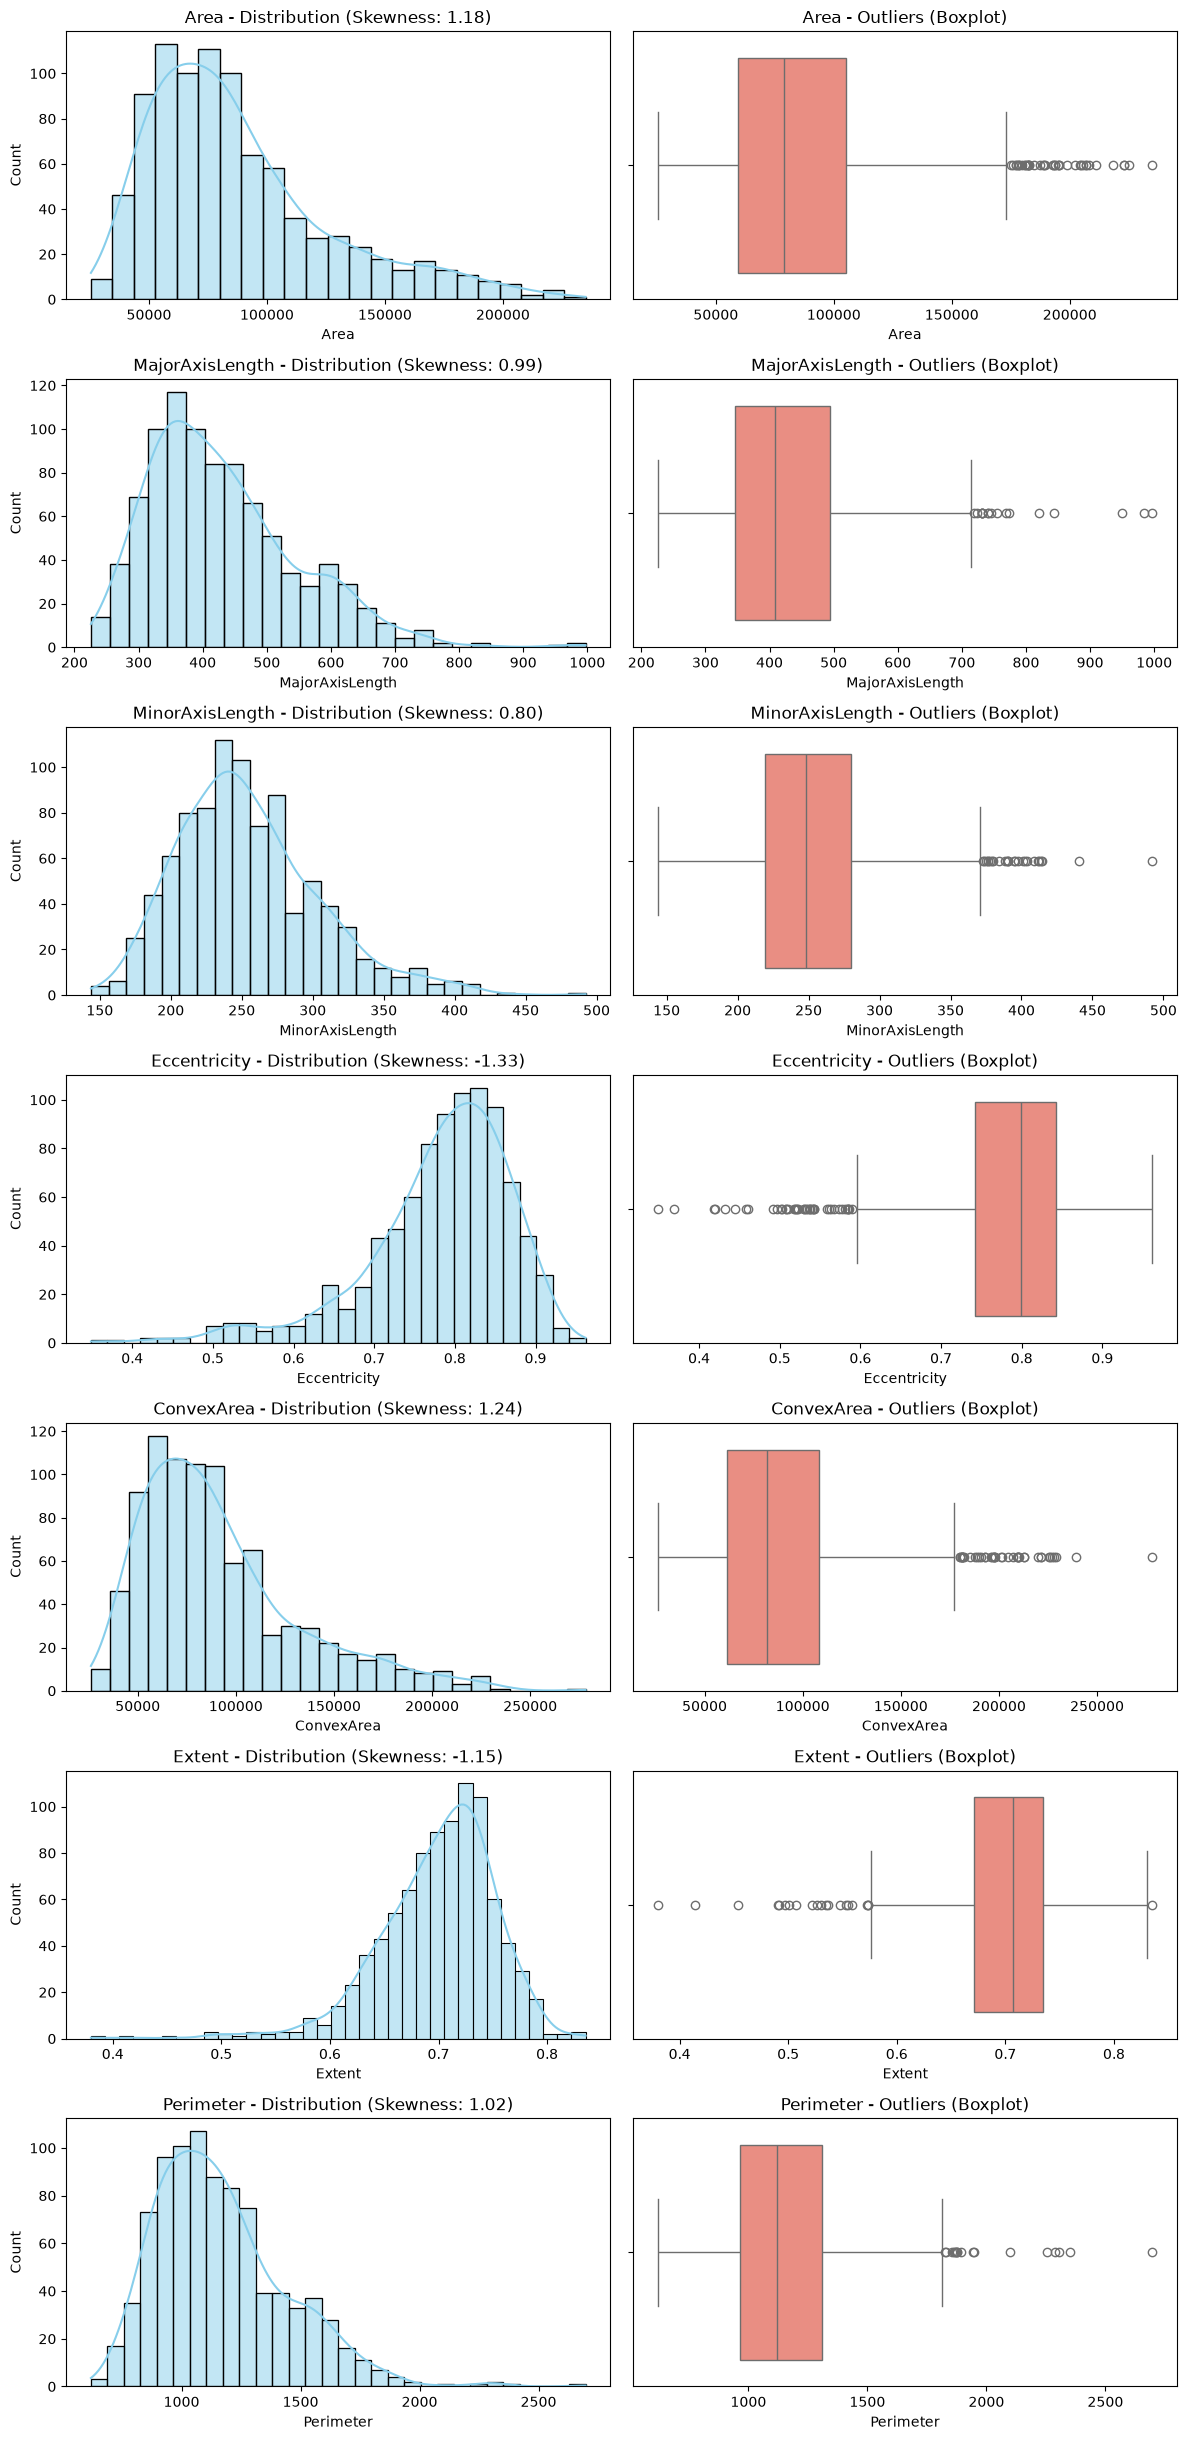

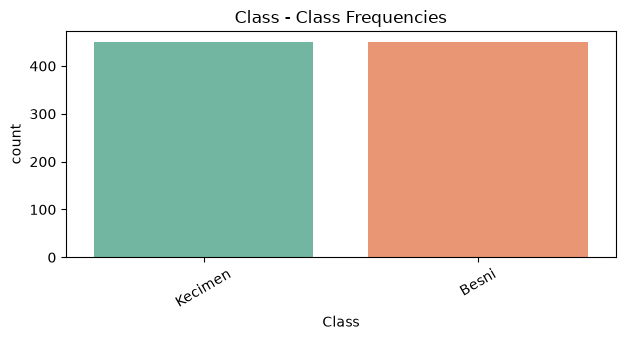

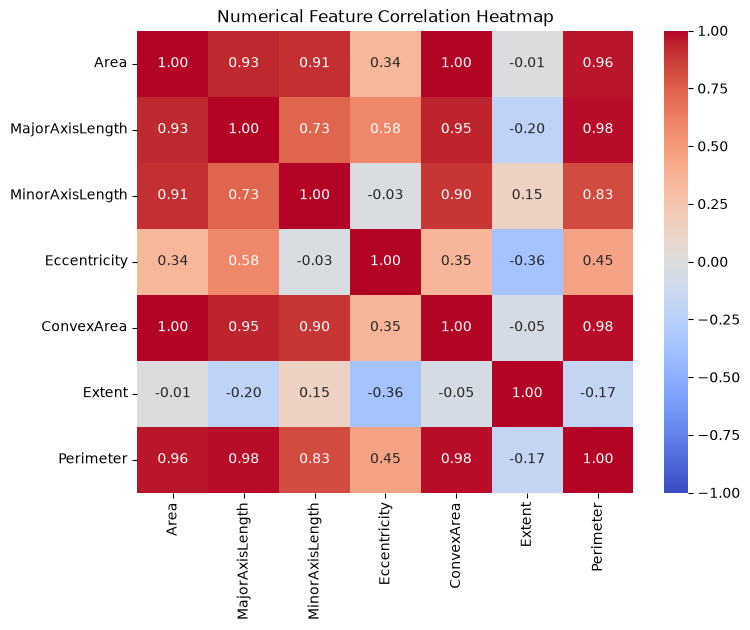

In [5]:
from ucimlrepo import fetch_ucirepo

# 1. 데이터셋 원본 그대로 로드
raisin = fetch_ucirepo(id=850)
raisin_df = raisin.data.original

run_comprehensive_eda(df=raisin_df)

# 2. 분석할 피처 리스트와 타겟 컬럼명 지정
raisin_features = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
target_column = 'Class'

# # 3. 보완된 함수 실행
# raisin_report = analyze_features_improved(
#     df=raisin_df, 
#     feature_cols=raisin_features, 
#     target_col=target_column
# )

기존 피처 개수: 7개
PCA 후 주성분 개수: 3개

각 주성분별 설명 분산 비율 (Explained Variance Ratio):
- PC1: 69.03%
- PC2: 20.76%
- PC3: 8.98%
총 누적 설명 분산: 98.77%


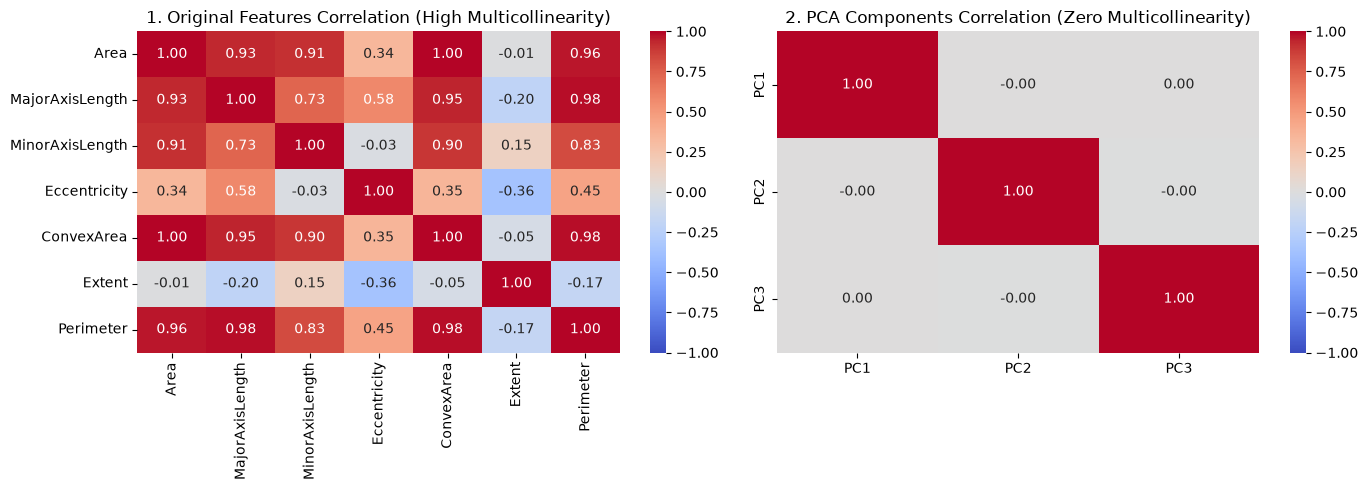

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo

# 1. 데이터 로드 및 X, y 분리
raisin = fetch_ucirepo(id=850)
df = raisin.data.original

X = df.drop(columns=['Class'])
y = df['Class']

# ---------------------------------------------------------
# Step 1. 피처 스케일링 (PCA 전 필수!)
# ---------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# ---------------------------------------------------------
# Step 2 & 3. PCA 적용 (분산의 95%를 보존하는 주성분 자동 선택)
# ---------------------------------------------------------
# n_components에 0.95를 전달하면 95% 분산을 설명하는 최소 주성분 개수를 자동 산출합니다.
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# 생성된 주성분 데이터프레임 변환
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)

print(f"기존 피처 개수: {X.shape[1]}개")
print(f"PCA 후 주성분 개수: {df_pca.shape[1]}개")
print("\n각 주성분별 설명 분산 비율 (Explained Variance Ratio):")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"- PC{i+1}: {ratio*100:.2f}%")
print(f"총 누적 설명 분산: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# ---------------------------------------------------------
# Step 4. 다중공선성 제거 결과 시각화 비교
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [원본 피처 상관계수 히트맵]
sns.heatmap(X_scaled_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("1. Original Features Correlation (High Multicollinearity)")

# [PCA 주성분 상관계수 히트맵]
sns.heatmap(df_pca.corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("2. PCA Components Correlation (Zero Multicollinearity)")

plt.tight_layout()
plt.show()

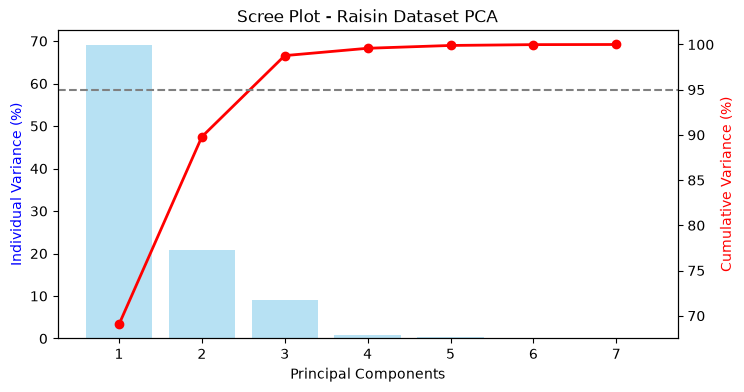

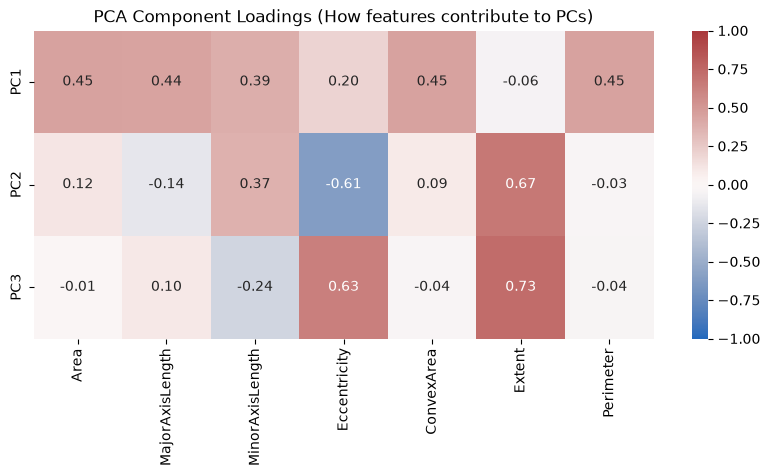

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo

# 데이터 로드 및 표준화
raisin = fetch_ucirepo(id=850)
X = raisin.data.original.drop(columns=['Class'])
X_scaled = StandardScaler().fit_transform(X)

# 전체 주성분(7개) 대상 PCA 수행
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# --- [시각화 1: 스크리 플롯] ---
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.bar(range(1, 8), pca_full.explained_variance_ratio_ * 100, alpha=0.6, color='skyblue', label='Individual Variance (%)')
ax1.set_xlabel('Principal Components')
ax1.set_ylabel('Individual Variance (%)', color='blue')

ax2 = ax1.twinx()
ax2.plot(range(1, 8), cum_var * 100, color='red', marker='o', linewidth=2, label='Cumulative Variance (%)')
ax2.axhline(y=95, color='gray', linestyle='--', label='95% Threshold')
ax2.set_ylabel('Cumulative Variance (%)', color='red')

plt.title('Scree Plot - Raisin Dataset PCA')
plt.show()

# --- [시각화 2: 원본 피처별 주성분 가중치 히트맵] ---
# 누적 95% 기준 주성분 추출 (3개)
pca_3 = PCA(n_components=3).fit(X_scaled)
loadings = pd.DataFrame(
    pca_3.components_, 
    columns=X.columns, 
    index=['PC1', 'PC2', 'PC3']
)

plt.figure(figsize=(10, 4))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap='vlag', vmin=-1, vmax=1)
plt.title('PCA Component Loadings (How features contribute to PCs)')
plt.show()

In [3]:
import pandas as pd

# pca는 n_components=3으로 fit을 완료한 객체
loadings = pd.DataFrame(
    pca.components_, 
    columns=X.columns, 
    index=['PC1', 'PC2', 'PC3']
)

# 피처별로 쉽게 보기 위해 행과 열을 뒤집음 (T)
print(loadings.T)

                      PC1       PC2       PC3
Area             0.448284  0.116100 -0.005484
MajorAxisLength  0.443240 -0.136587  0.100548
MinorAxisLength  0.389381  0.374922 -0.236044
Eccentricity     0.202971 -0.610823  0.628522
ConvexArea       0.450938  0.087616 -0.036672
Extent          -0.056368  0.667344  0.731981
Perimeter        0.450824 -0.034172 -0.044301


In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

def plot_pair_grid(df, features=None, target=None, diag_kind='hist', alpha=0.55, s=20):
    """
    Seaborn의 PairGrid를 활용해 주요 특성 조합을 격자(Grid) 산점도로 출력하는 함수
    
    :param df: pandas DataFrame
    :param features: 시각화할 컬럼명 리스트 (None일 경우 수치형 컬럼 최대 5개 자동 선택)
    :param target: 그룹화할 범주형 타겟 컬럼명
    :param diag_kind: 대각선 그래프 종류 ('hist': 히스토그램, 'kde': 밀도 그래프)
    :param alpha: 산점도 투명도 (기본값: 0.55)
    :param s: 점 크기 (기본값: 20)
    """
    # 1. 시각화할 수치형 특성 자동 선택
    if features is None:
        numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
        if target in numeric_cols:
            numeric_cols.remove(target)
        features = numeric_cols[:10]  # 시각성 보장을 위해 기본 최대 5개 선택

    # 2. PairGrid 객체 생성
    g = sns.PairGrid(df, vars=features, hue=target, palette='tab10')

    # 3. 대각선 바깥 영역: 산점도(Scatter Plot)
    g.map_offdiag(
        sns.scatterplot, 
        alpha=alpha, 
        s=s, 
        edgecolor='white', 
        linewidth=0.3
    )

    # 4. 대각선 영역: 히스토그램 또는 KDE 그래프
    if diag_kind == 'kde':
        g.map_diag(sns.kdeplot, alpha=alpha, fill=True)
    else:
        g.map_diag(sns.histplot, alpha=alpha, element='step')

    # 5. 범례 및 타이틀 스타일 설정
    if target:
        g.add_legend(title=target, bbox_to_anchor=(1.02, 0.5), loc='center left', frameon=True)
    
    g.fig.suptitle("Pairwise Feature Grid Plot", y=1.02, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.pyplot as plt
import pandas as pd

def plot_multi_features(df, features=None, x_axis=None, normalize=False, s=25, alpha=0.75):
    """
    여러 특성(Feature)을 명확히 대비되는 고시인성 색상으로 하나의 그래프에 출력하는 함수
    
    :param df: pandas DataFrame
    :param features: 시각화할 컬럼명 리스트 (None이면 모든 수치형 컬럼 자동 선택)
    :param x_axis: X축으로 사용할 컬럼명 (None이면 데이터의 행 인덱스 사용)
    :param normalize: True 설정 시 0~1(Min-Max) 스케일링 적용
    :param s: 점 크기 (기본값: 25)
    :param alpha: 투명도 (기본값: 0.75)
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. 특성 컬럼 선택
    if features is None:
        features = df.select_dtypes(include=['number']).columns.tolist()
        if x_axis in features:
            features.remove(x_axis)

    # 2. 시인성과 대비가 극대화된 원색계열 팔레트 지정 (최대 10개)
    high_contrast_colors = [
        '#E6194B',  # Vibrant Red (빨강)
        '#4363D8',  # Royal Blue (파랑)
        '#3CB44B',  # Bright Green (초록)
        '#F58231',  # Orange (주황)
        '#911EB4',  # Purple (보라)
        '#00D8F6',  # Cyan (하늘/시안)
        '#F032E6',  # Magenta (분홍/마젠타)
        '#808000',  # Olive (올리브)
        '#9A6324',  # Brown (갈색)
        '#000000'   # Black (검정)
    ]

    # 3. X축 데이터 설정
    x_data = df[x_axis] if (x_axis and x_axis in df.columns) else df.index
    x_label = x_axis if x_axis else "Index"

    # 4. 데이터 정규화(Min-Max Scaling)
    plot_df = df[features].copy()
    if normalize:
        plot_df = (plot_df - plot_df.min()) / (plot_df.max() - plot_df.min() + 1e-9)

    # 5. 대비가 선명한 색상 및 얇은 검은색 테두리로 시인성 강화
    for i, col in enumerate(features):
        color = high_contrast_colors[i % len(high_contrast_colors)]
        ax.scatter(
            x_data, 
            plot_df[col], 
            label=col, 
            color=color,
            s=s, 
            alpha=alpha, 
            edgecolors='black',  # 테두리를 검은색으로 마감하여 점 경계 구분
            linewidths=0.5
        )

    # 6. 축 및 타이틀 설정
    ax.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax.set_ylabel("Normalized Value (0~1)" if normalize else "Value", fontsize=11, fontweight='bold')
    
    title_suffix = " (Min-Max Normalized)" if normalize else ""
    ax.set_title(f"Multi-Feature Distribution{title_suffix}", fontsize=13, pad=12)

    # 범례 및 그리드
    ax.legend(title="Features", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()
    
def analyze_features(df, feature_cols, target_col, is_classification=True):
    """
    개선된 피처 분석 함수:
    - 수치형 피처 중심의 VIF 및 Mutual Information(상호 정보량) 기반 통합 분석 리포트 제공
    """
    df_analyzed = df.copy()
    
    # 1. 타겟 변수 안전 인코딩
    if is_classification and (df_analyzed[target_col].dtype in ['object', 'string', 'category']):
        le = LabelEncoder()
        df_analyzed[target_col] = le.fit_transform(df_analyzed[target_col].astype(str))
    
    # 2. 수치형 피처만 구분하여 추출 (VIF 및 상관분석용)
    numeric_features = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df_analyzed[col])]
    
    if len(numeric_features) < len(feature_cols):
        ignored = set(feature_cols) - set(numeric_features)
        print(f"[주의] 수치형이 아닌 피처 {list(ignored)}는 VIF/상관관계 분석에서 제외되었습니다.")

    X_num = df_analyzed[numeric_features].copy()
    X_num = X_num.fillna(X_num.median()) # EDA용 결측치 임시 처리
    y = df_analyzed[target_col].fillna(df_analyzed[target_col].mode()[0])

    # 3. Mutual Information (비선형 포함 전체적인 의존도 측정)
    if is_classification:
        mi_scores = mutual_info_classif(X_num, y, random_state=42)
    else:
        mi_scores = mutual_info_regression(X_num, y, random_state=42)
    
    # 4. VIF 계산 (상수항 추가)
    X_vif = X_num.copy()
    X_vif['intercept'] = 1.0
    
    vif_list = []
    for i in range(X_num.shape[1]):
        try:
            vif = variance_inflation_factor(X_vif.values, i)
            vif_list.append(vif)
        except Exception:
            vif_list.append(np.nan)

    # 5. 리포트 생성
    report_df = pd.DataFrame({
        'Feature': numeric_features,
        'Mutual_Info': mi_scores,
        'Pearson_Corr_Abs': X_num.corrwith(y).abs().values,
        'VIF_Score': vif_list
    }).sort_values(by='Mutual_Info', ascending=False).reset_index(drop=True)

    print("\n" + "="*60)
    print("         [개선된 변수 분석 통합 리포트]         ")
    print("="*60)
    print(report_df.round(4))
    print("="*60)
    print("* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심하세요.\n")

    # 7. 분포 시각화
    print("\n[시각화] 변수별 품종 분리도 시각화를 출력합니다...")
    num_features = len(feature_cols)
    cols_per_row = 4
    rows = (num_features + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(5 * cols_per_row, 5 * rows))
    if rows == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        # 시각화 데이터는 원본 df를 사용하되 타겟별 정상 분리 형태 유지
        # 수정 전 Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 
        #sns.boxplot(data=df, x=target_col, y=pd.to_numeric(df[col], errors='coerce'), ax=axes[i], palette='Set2')
        # 수정 후
        sns.boxplot(data=df, x=target_col, y=pd.to_numeric(df[col], errors='coerce'), ax=axes[i], hue=target_col, palette='Set2', legend=False)

        axes[i].set_title(f'{col} by {target_col}')
        axes[i].set_xlabel('')

    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    return report_df


         [개선된 변수 분석 통합 리포트]         
           Feature  Mutual_Info  Pearson_Corr_Abs  VIF_Score
0        Perimeter       0.3585            0.6660   184.2528
1  MajorAxisLength       0.3483            0.6732   129.1529
2       ConvexArea       0.2975            0.6256   445.9476
3             Area       0.2776            0.6257   404.7188
4  MinorAxisLength       0.1349            0.5031    40.1666
5     Eccentricity       0.1291            0.4385     5.2104
6           Extent       0.0293            0.1547     1.6053
* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심하세요.


[시각화] 변수별 품종 분리도 시각화를 출력합니다...


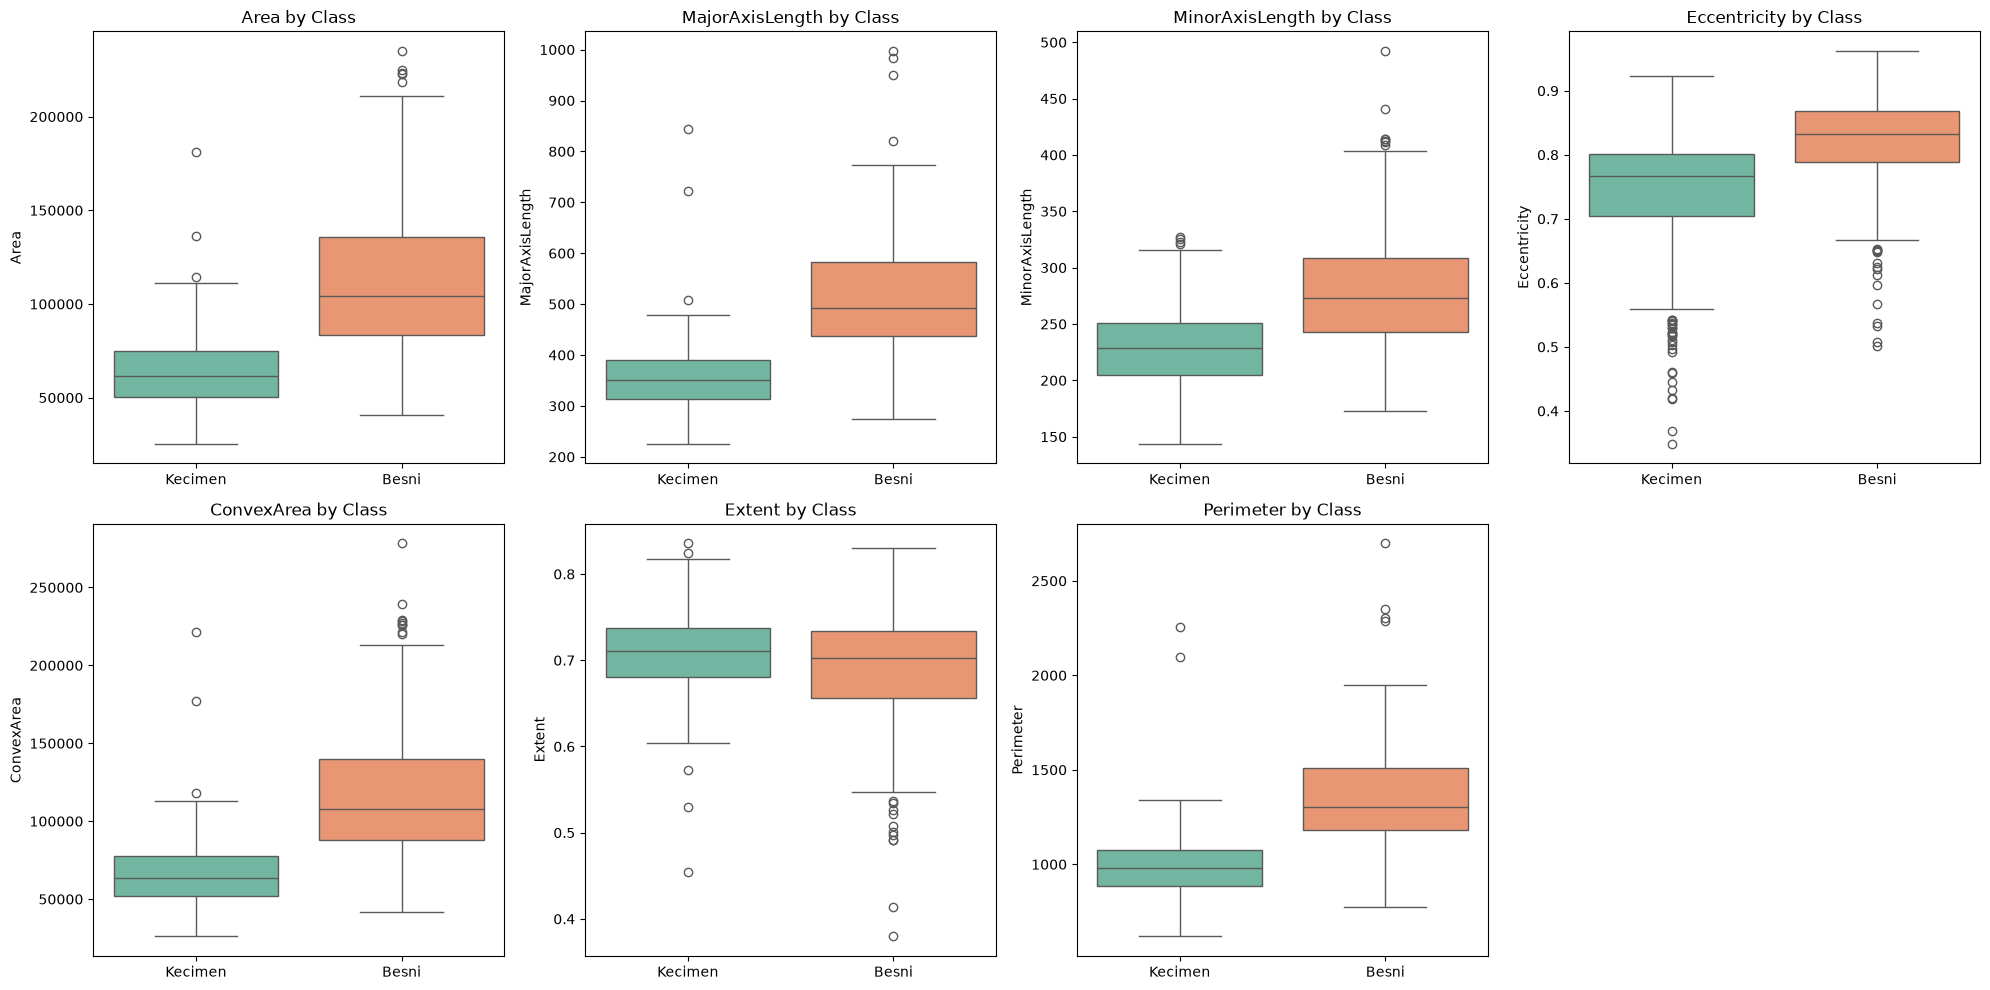

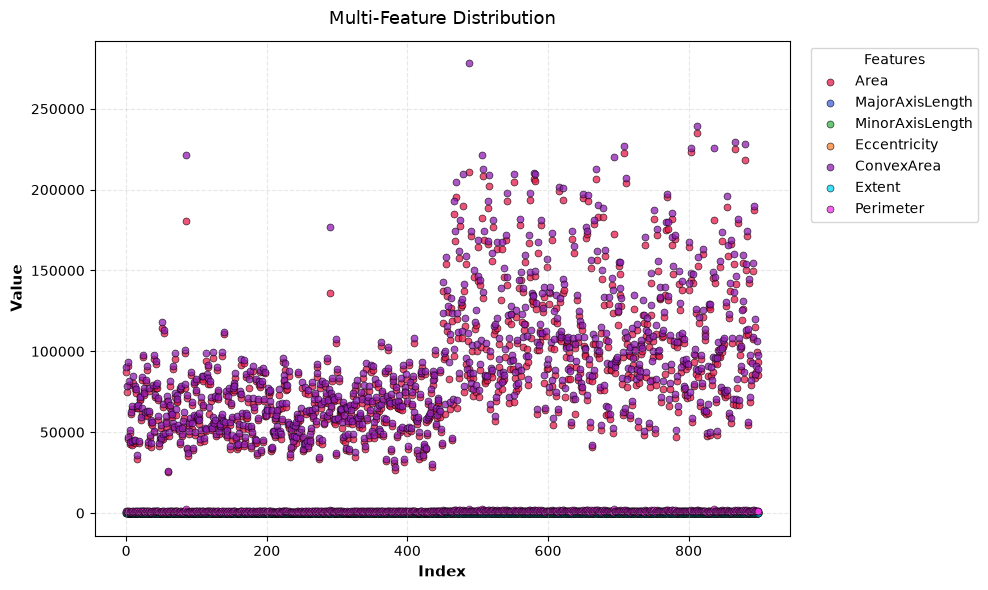

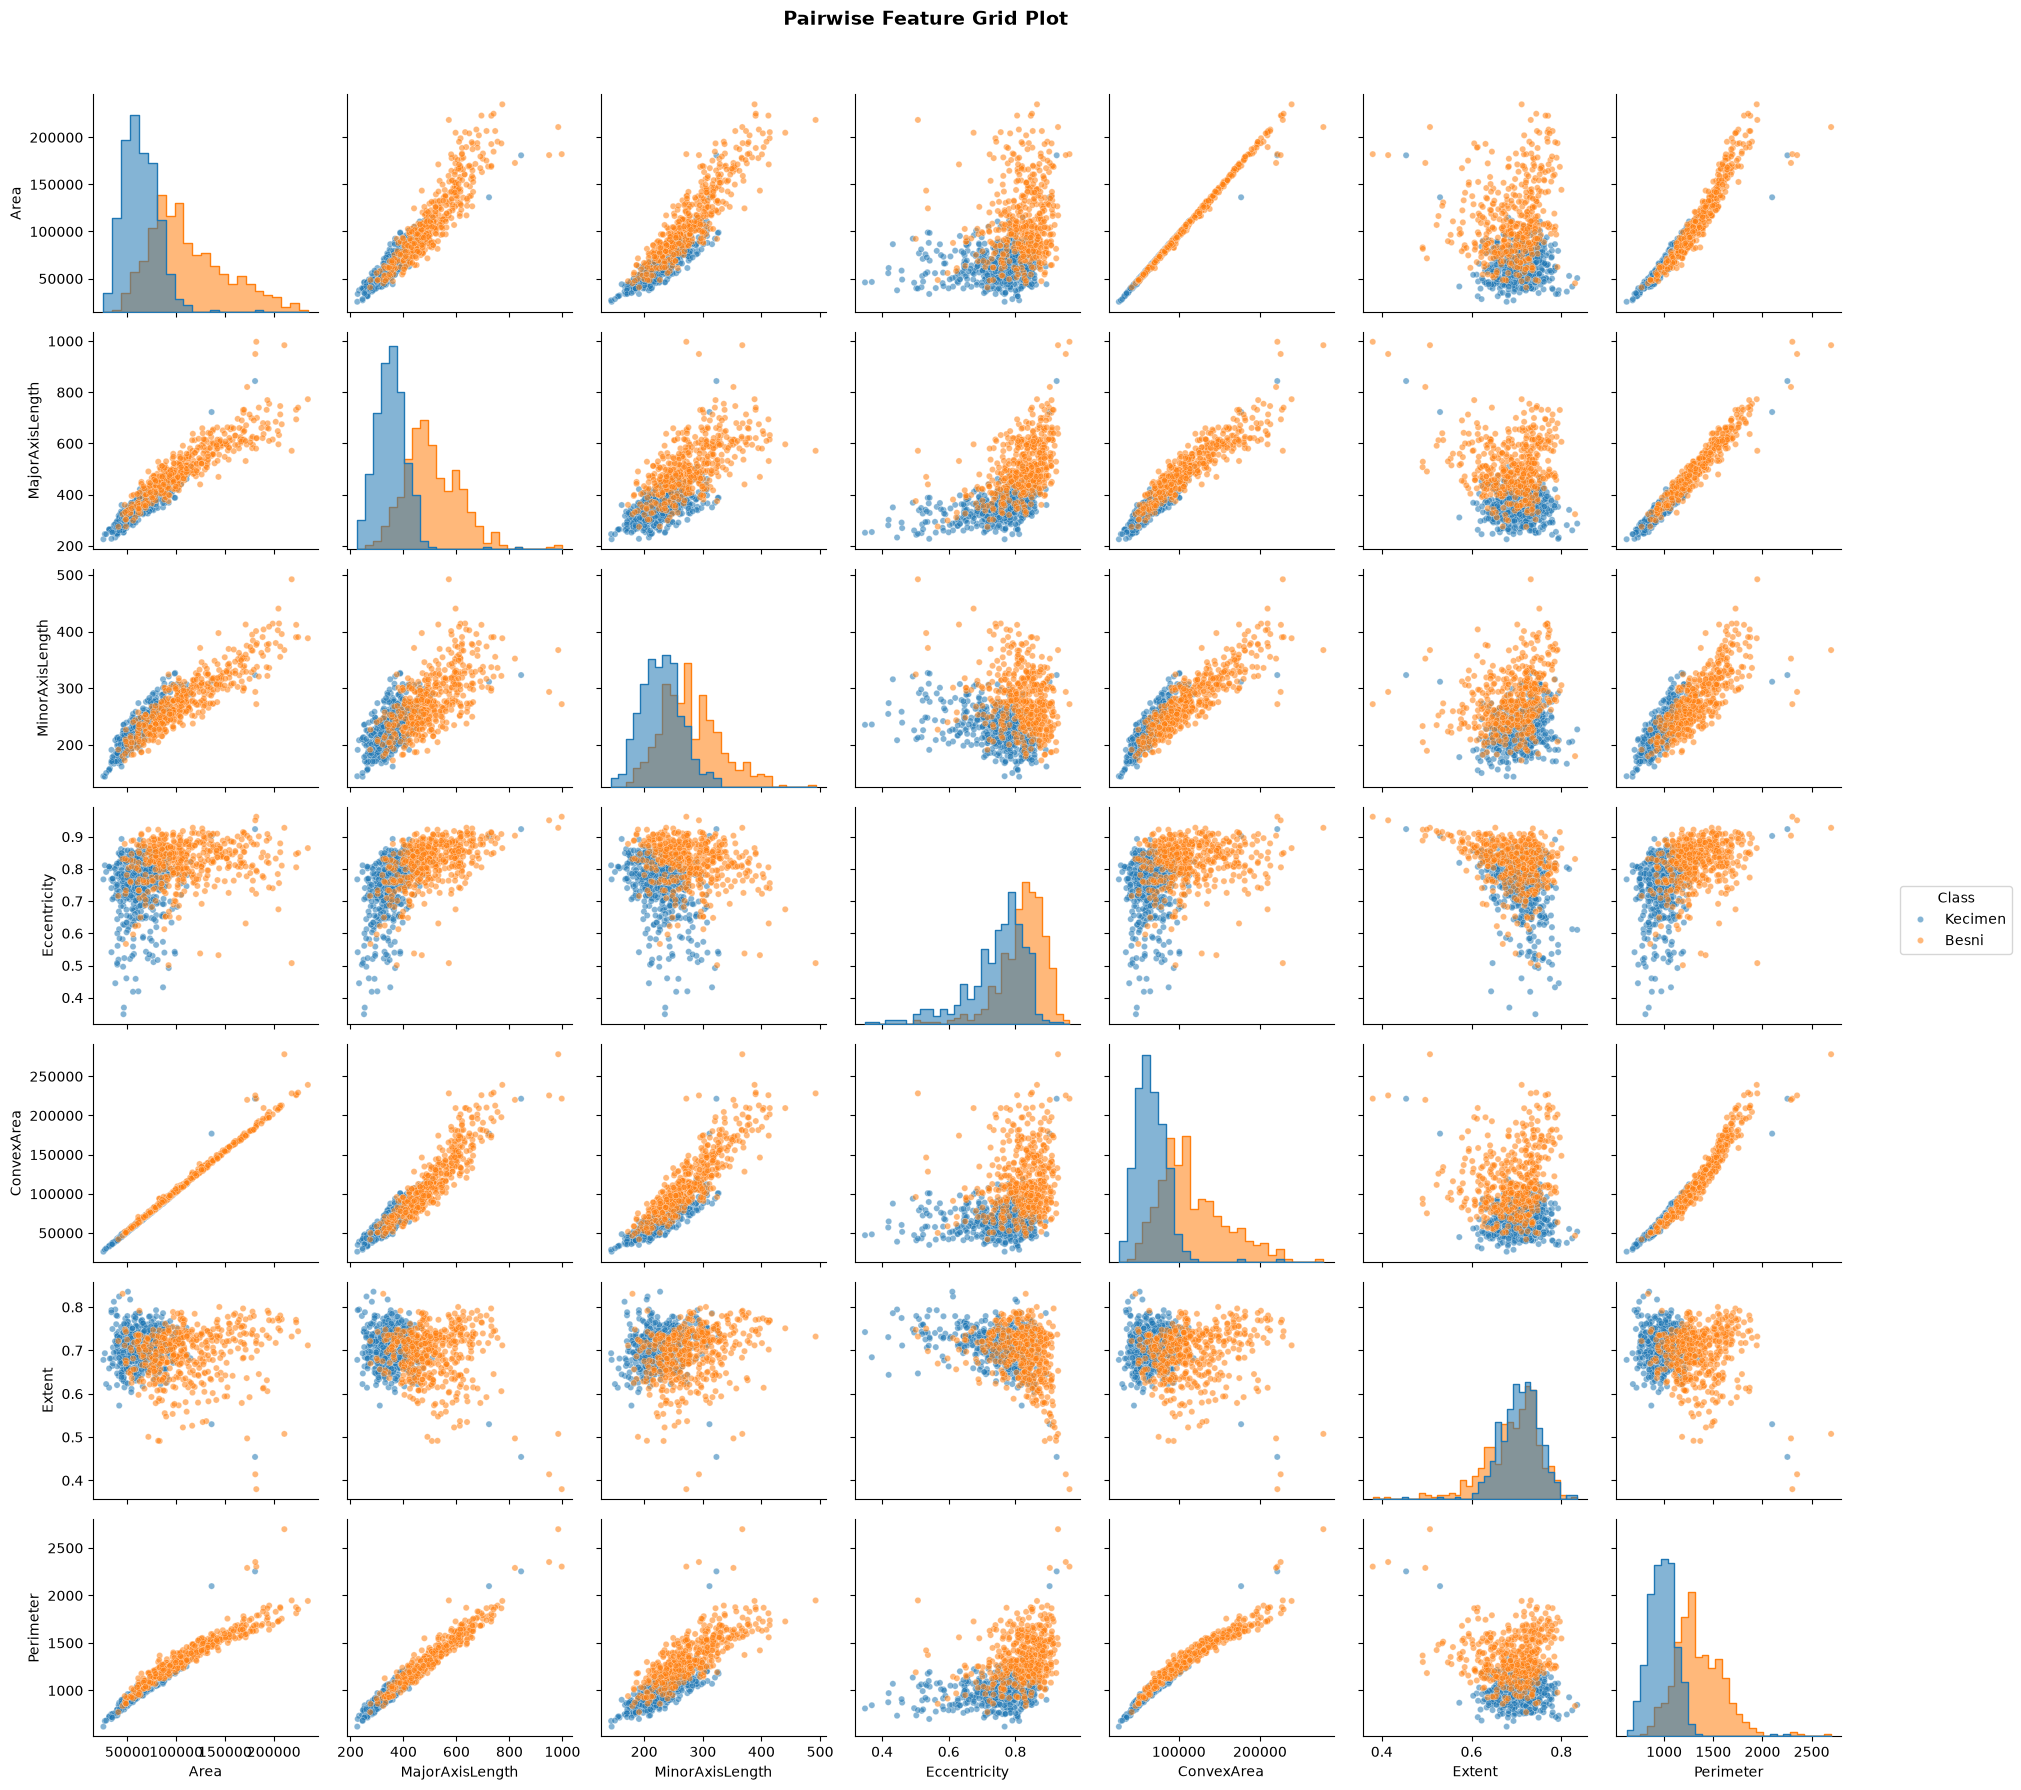

In [38]:
from ucimlrepo import fetch_ucirepo

# 1. 데이터셋 원본 
raisin = fetch_ucirepo(id=850)
data_df = raisin.data.original

# 2. 분석할 피처 리스트와 타겟 컬럼명 지정
features = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
target_column = 'Class'

# 3. 리포트 함수 실행
raisin_report = analyze_features(
    df=data_df, 
    feature_cols=features, 
    target_col=target_column
)
# 4. 산점도 함수 실행
plot_multi_features(df=data_df)

# 5. 산점도 2개의 features 함수 실행
# 1) 기본 실행 (자동 수치형 컬럼 선택 및 히스토그램)
plot_pair_grid(df=data_df, target=target_column)

# 2) 특정 특성만 지정 + 대각선에 밀도 추정(KDE) 적용
# plot_pair_grid(df=data_df, features=features, target=target_column, diag_kind='kde')

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

def analyze_features_for_selection(df, feature_cols, target_col):
    """
    임의의 데이터셋에 대해 타겟 상관관계와 다중공선성(VIF)을 분석하여 변수 선택 리포트를 생성합니다.
    피처 데이터 내에 문자열이 오염되어 섞여 있어도 완전히 강제 숫자로 정제하여 계산합니다.
    """
    print(f"\n[알림] 총 {len(feature_cols)}개의 변수와 타겟 '{target_col}'에 대한 분석을 시작합니다.")
    
    # 1. 안전하게 독립변수(X) 추출 및 데이터 타입 강제 정제
    X = pd.DataFrame()
    for col in feature_cols:
        # errors='coerce'를 사용하면 'Kecimen' 같은 잘못 섞인 문자열은 모두 NaN(결측치)으로 바뀝니다.
        X[col] = pd.to_numeric(df[col], errors='coerce')
        
    y = df[target_col].copy()
    
    # 2. 강제 변환 후 발생한 결측치 처리 (중간값으로 대체하여 연산 에러 방지)
    if X.isnull().sum().sum() > 0:
        print("[주의] 수치형 변수 내에 문자열 오염 또는 결측치가 발견되어 자동으로 수치 정제 및 대체 처리를 수행했습니다.")
        X = X.fillna(X.median())
        
    # 3. 타겟 변수 인코딩 처리 (문자형 데이터 'Kecimen', 'Besni' 등을 0, 1로 변환)
    if y.dtype == 'str' or y.dtype == 'object' or y.dtype.name == 'category':
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        print(f"[정보] 타겟 변수 '{target_col}'가 문자형이므로 라벨 인코딩을 적용했습니다. (클래스: {le.classes_})")
    else:
        y_encoded = y.values

    # 4. 타겟(Y)과의 상관관계 계산 (정제된 X 데이터와 1:1 매칭 확인)
    y_series = pd.Series(y_encoded, index=X.index)
    target_corr = X.corrwith(y_series).abs()

    # 5. 다중공선성(VIF) 계산
    X_vif = X.copy()
    X_vif['intercept'] = 1.0

    vif_values = []
    for i in range(len(feature_cols)):
        try:
            vif = variance_inflation_factor(X_vif.values, i)
            vif_values.append(vif)
        except Exception as e:
            vif_values.append(np.nan)
            print(f"[오류] {feature_cols[i]} 변수의 VIF 계산 실패: {e}")

    # 6. 실무용 통합 의사결정 리포트 생성
    report_df = pd.DataFrame({
        'Target_Correlation_Abs': target_corr,
        'VIF_Score': vif_values
    })

    # 타겟 기여도가 높은 순서 정렬
    report_df = report_df.sort_values(by='Target_Correlation_Abs', ascending=False)

    print("\n" + "="*60)
    print("       [실무 의사결정용 변수 분석 통합 리포트]       ")
    print("="*60)
    print(report_df.round(4))
    print("="*60)
    print("* 가이드라인: Target_Correlation은 높을수록 핵심 변수이며,")
    print("              VIF_Score가 10 이상이면 중복 변수이므로 제외를 검토하세요.\n")

    # 7. 분포 시각화
    print("[알림] 변수별 품종 분리도 시각화를 출력합니다...")
    num_features = len(feature_cols)
    cols_per_row = 4
    rows = (num_features + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(5 * cols_per_row, 5 * rows))
    if rows == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        # 시각화 데이터는 원본 df를 사용하되 타겟별 정상 분리 형태 유지
        # 수정 전 Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 
        #sns.boxplot(data=df, x=target_col, y=pd.to_numeric(df[col], errors='coerce'), ax=axes[i], palette='Set2')
        # 수정 후
        sns.boxplot(data=df, x=target_col, y=pd.to_numeric(df[col], errors='coerce'), ax=axes[i], hue=target_col, palette='Set2', legend=False)

        axes[i].set_title(f'{col} by {target_col}')
        axes[i].set_xlabel('')

    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
    
    return report_df


[알림] 총 7개의 변수와 타겟 'Class'에 대한 분석을 시작합니다.
[정보] 타겟 변수 'Class'가 문자형이므로 라벨 인코딩을 적용했습니다. (클래스: ['Besni' 'Kecimen'])

       [실무 의사결정용 변수 분석 통합 리포트]       
                 Target_Correlation_Abs  VIF_Score
MajorAxisLength                  0.6732   129.1529
Perimeter                        0.6660   184.2528
Area                             0.6257   404.7188
ConvexArea                       0.6256   445.9476
MinorAxisLength                  0.5031    40.1666
Eccentricity                     0.4385     5.2104
Extent                           0.1547     1.6053
* 가이드라인: Target_Correlation은 높을수록 핵심 변수이며,
              VIF_Score가 10 이상이면 중복 변수이므로 제외를 검토하세요.

[알림] 변수별 품종 분리도 시각화를 출력합니다...


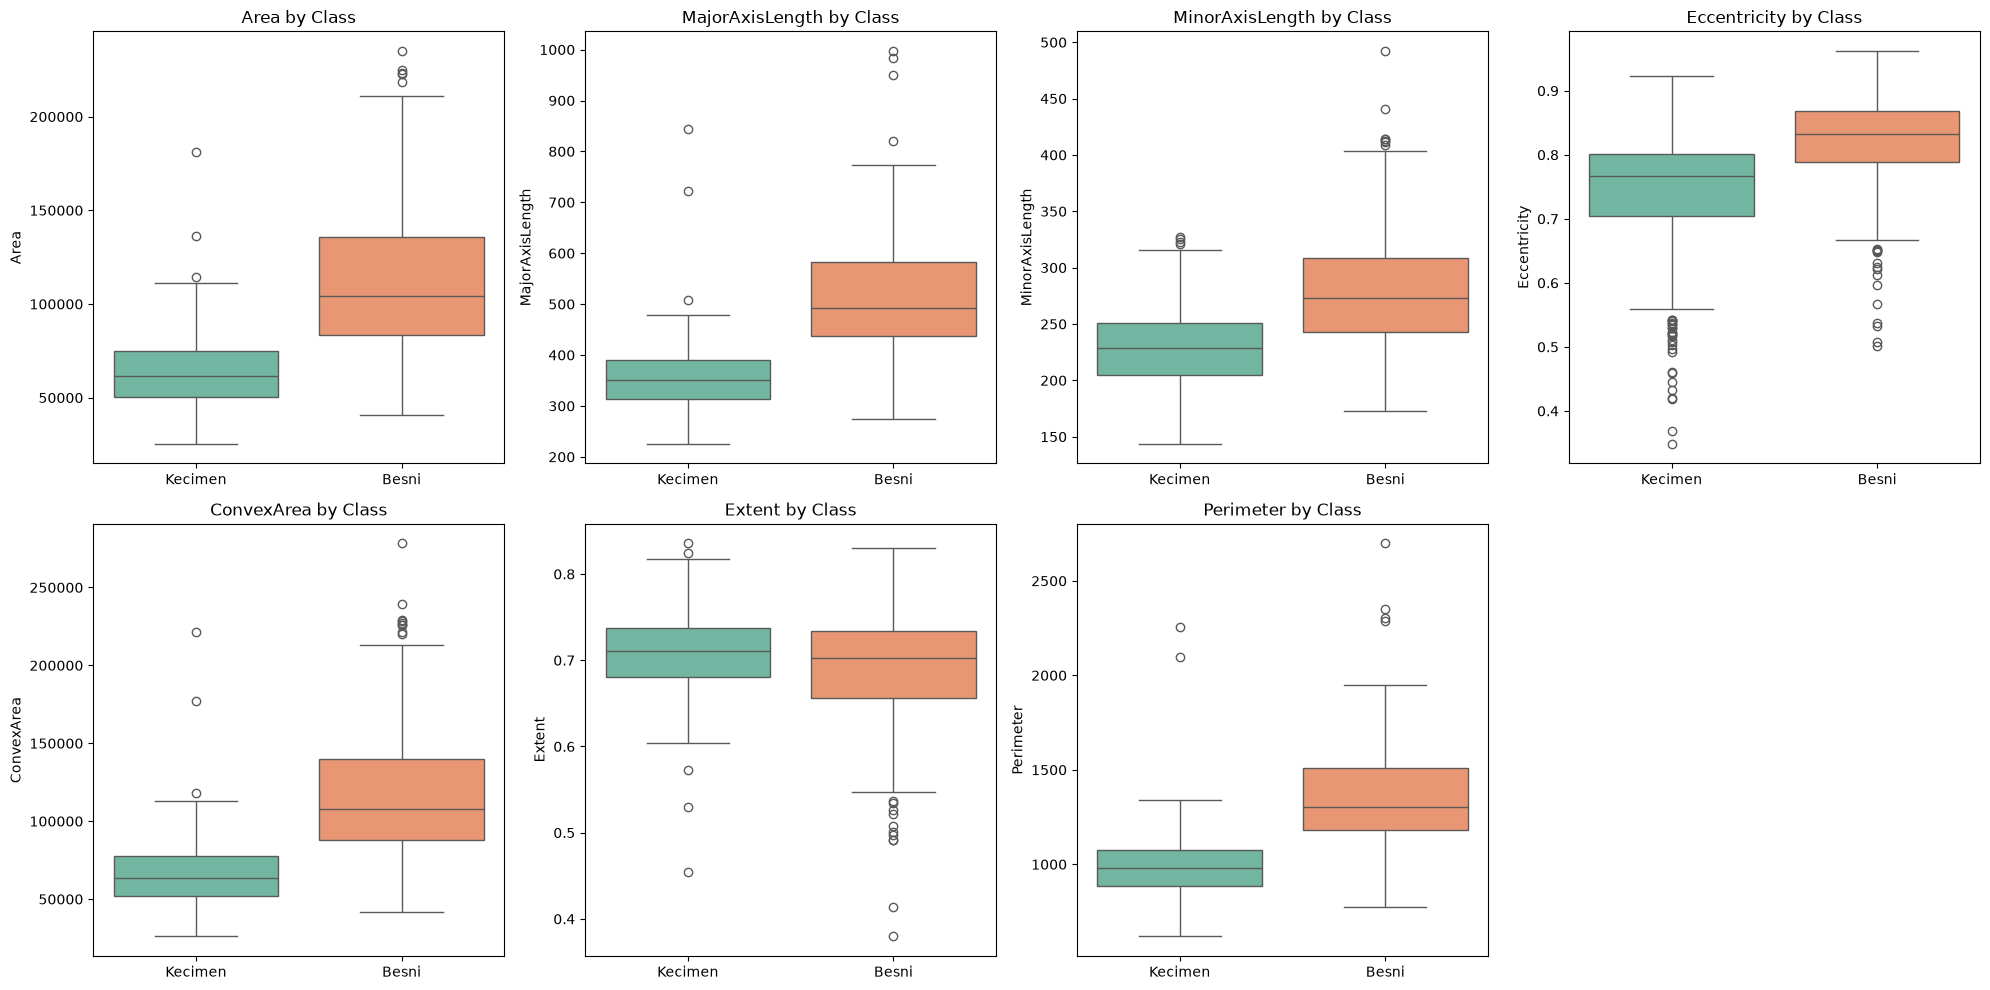

In [6]:
from ucimlrepo import fetch_ucirepo

# 1. 데이터셋 원본 그대로 로드
raisin = fetch_ucirepo(id=850)
raisin_df = raisin.data.original

# 2. 분석할 피처 리스트와 타겟 컬럼명 지정
raisin_features = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
target_column = 'Class'

# 3. 보완된 함수 실행
raisin_report = analyze_features_for_selection(
    df=raisin_df, 
    feature_cols=raisin_features, 
    target_col=target_column
)

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def plot_pair(f1, f2):
    for label, g in train_df.groupby('Class'):
        plt.scatter(g[f1], g[f2], s=20, alpha=.55, label=label)
    plt.xlabel(f1); plt.ylabel(f2); plt.legend(); plt.grid(alpha=.15)
    plt.title(f"{f1} vs {f2} - train df -")
    plt.show()

from ucimlrepo import fetch_ucirepo
df = fetch_ucirepo(id=850).data.original

dev_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Class'], random_state=42)
train_df, valid_df = train_test_split(dev_df, test_size=0.2, stratify=dev_df['Class'], random_state=42)

y_train, y_valid, y_test = train_df['Class'], valid_df['Class'], test_df['Class']
FEATURES = [i for i in df.columns if i !='Class']

print("train", len(train_df), "/ validation", len(valid_df), "/ test", len(test_df))
print("class", dict(df["Class"].value_counts()))
print("features", FEATURES)
print("baseline(찍기)", 0.5)
print(pd.DataFrame(train_df.groupby('Class')))
print(train_df.head())


train 576 / validation 144 / test 180
class {'Kecimen': np.int64(450), 'Besni': np.int64(450)}
features ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
baseline(찍기) 0.5
         0                                                  1
0    Besni         Area  MajorAxisLength  MinorAxisLength ...
1  Kecimen         Area  MajorAxisLength  MinorAxisLength ...
       Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
475  177264       619.958472       366.763240      0.806237      180994   
39    49882       287.264327       222.185873      0.633852       50880   
192   37569       232.427848       208.152006      0.444950       38874   
585   61444       371.693826       213.179806      0.819180       64321   
535   77012       425.219427       239.469561      0.826343       81325   

       Extent  Perimeter    Class  
475  0.683219   1652.694    Besni  
39   0.766378    843.764  Kecimen  
192  0.794371    734.102  Kecimen 

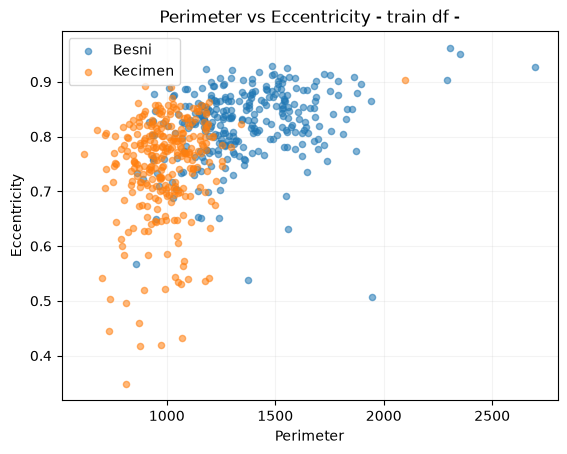

Perimeter + Eccentricity train CV = 0.8454 


In [19]:
F1, F2 = "Perimeter", "Eccentricity" 
X_train, X_valid = train_df[[F1,F2]] , valid_df[[F1,F2 ]]

plot_pair(F1,F2)
pair_cv = cross_val_score(
    Pipeline( [ ("s", StandardScaler()), ("k", KNeighborsClassifier(5)) ] ),
    X_train, y_train, cv=5
).mean()
print(f"{F1} + {F2} train CV = {pair_cv:.4f} ")



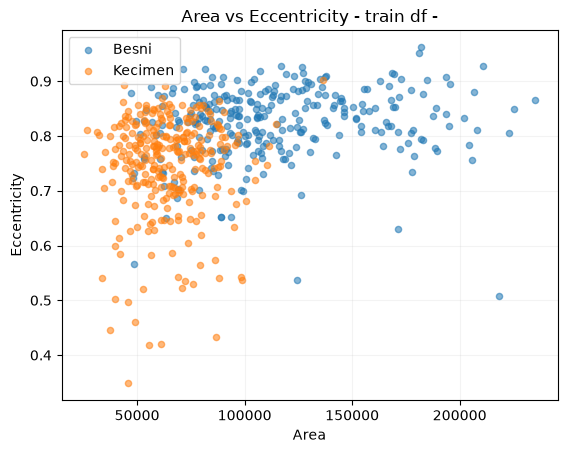

Area + Eccentricity train CV = 0.8264 


In [27]:
F1, F2 = "Area", "Eccentricity" 
X_train, X_valid = train_df[[F1,F2]] , valid_df[[F1,F2 ]]

plot_pair(F1,F2)
pair_cv = cross_val_score(
    Pipeline( [ ("s", StandardScaler()), ("k", KNeighborsClassifier(5)) ] ),
    X_train, y_train, cv=5
).mean()
print(f"{F1} + {F2} train CV = {pair_cv:.4f} ")



In [28]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# 1. Train 데이터와 Test 데이터 준비
train_data = pd.DataFrame({'Fruit': ['Apple', 'Banana', 'Cherry', 'Apple']})
test_data = pd.DataFrame({'Fruit': ['Banana', 'Apple', 'Orange']})  # 'Orange'는 미학습 데이터

# 2. OneHotEncoder 인스턴스 생성
# handle_unknown='ignore': Test에 새로운 범주가 있어도 에러 없이 모두 0으로 처리
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 3. Train 데이터: fit_transform() 사용 (카테고리 목록 학습 + 변환)
train_encoded = encoder.fit_transform(train_data)
print("--- [Train] fit_transform 결과 ---")
print(pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out()))

# 4. Test 데이터: transform() 사용 (기존 학습 기준 그대로 변환)
test_encoded = encoder.transform(test_data)
print("\n--- [Test] transform 결과 ---")
print(pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out()))

--- [Train] fit_transform 결과 ---
   Fruit_Apple  Fruit_Banana  Fruit_Cherry
0          1.0           0.0           0.0
1          0.0           1.0           0.0
2          0.0           0.0           1.0
3          1.0           0.0           0.0

--- [Test] transform 결과 ---
   Fruit_Apple  Fruit_Banana  Fruit_Cherry
0          0.0           1.0           0.0
1          1.0           0.0           0.0
2          0.0           0.0           0.0


In [23]:
import matplotlib.pyplot as plt

def plot_pair(df, x, y, target='Class', s=20, alpha=0.55):
    """
    DataFrame의 두 특성(f1, f2)을 타겟 범주별로 구분하여 산점도를 그리는 함수
    
    :param df: pandas DataFrame
    :param x: X축 컬럼명
    :param y: Y축 컬럼명
    :param target: 그룹화할 타겟 컬럼명 (기본값: 'Class')
    :param s: 점 크기 (기본값: 20)
    :param alpha: 투명도 (기본값: 0.55)
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Target 클래스별로 그룹화하여 산점도 출력 (색상 자동 할당)
    for label, g in df.groupby(target):
        ax.scatter(g[x], g[y], s=s, alpha=alpha, label=label, edgecolors='white', linewidths=0.3)

    # 축 라벨 및 타이틀 설정
    ax.set_xlabel(x, fontsize=11, fontweight='bold')
    ax.set_ylabel(y, fontsize=11, fontweight='bold')
    ax.set_title(f"{x} vs {y} ({target})", fontsize=13, pad=12)

    # 범례(Legend)를 그래프 우측 외곽에 배치하여 데이터 가림 방지
    ax.legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    ax.grid(True, linestyle='--', alpha=0.15)

    plt.tight_layout()
    plt.show()

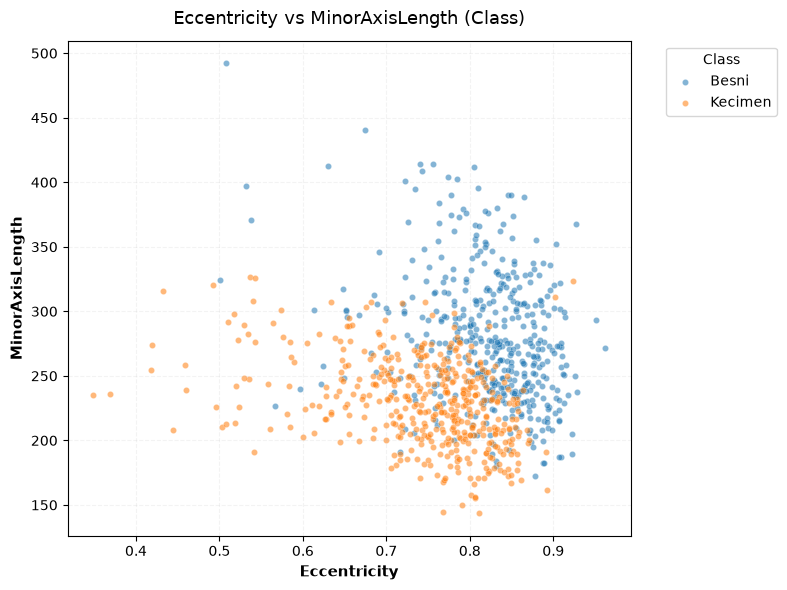

In [24]:
import numpy as np

# 1. 데이터셋 원본 그대로 로드
raisin = fetch_ucirepo(id=850)
raisin_df = raisin.data.original

# 2. 분석할 피처 리스트와 타겟 컬럼명 지정
raisin_features = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
target_column = 'Class'

# 1) 변수 2개 사용 (X, Y)
plot_pair(df=raisin_df, x='Eccentricity', y='MinorAxisLength', target='Class' )

# # 2) 변수 3개 사용 (X, Y + 색상)
# plot_scatter(df, x='height', y='weight', color='age')

# # 3) 변수 4개 사용 (X, Y + 색상 + 점 크기)
# plot_scatter(df, x='height', y='weight', color='age', size='income')

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_pair_grid(df, features=None, target=None, diag_kind='hist', alpha=0.55, s=20):
    """
    Seaborn의 PairGrid를 활용해 주요 특성 조합을 격자(Grid) 산점도로 출력하는 함수
    
    :param df: pandas DataFrame
    :param features: 시각화할 컬럼명 리스트 (None일 경우 수치형 컬럼 최대 5개 자동 선택)
    :param target: 그룹화할 범주형 타겟 컬럼명
    :param diag_kind: 대각선 그래프 종류 ('hist': 히스토그램, 'kde': 밀도 그래프)
    :param alpha: 산점도 투명도 (기본값: 0.55)
    :param s: 점 크기 (기본값: 20)
    """
    # 1. 시각화할 수치형 특성 자동 선택
    if features is None:
        numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
        if target in numeric_cols:
            numeric_cols.remove(target)
        features = numeric_cols[:10]  # 시각성 보장을 위해 기본 최대 5개 선택

    # 2. PairGrid 객체 생성
    g = sns.PairGrid(df, vars=features, hue=target, palette='tab10')

    # 3. 대각선 바깥 영역: 산점도(Scatter Plot)
    g.map_offdiag(
        sns.scatterplot, 
        alpha=alpha, 
        s=s, 
        edgecolor='white', 
        linewidth=0.3
    )

    # 4. 대각선 영역: 히스토그램 또는 KDE 그래프
    if diag_kind == 'kde':
        g.map_diag(sns.kdeplot, alpha=alpha, fill=True)
    else:
        g.map_diag(sns.histplot, alpha=alpha, element='step')

    # 5. 범례 및 타이틀 스타일 설정
    if target:
        g.add_legend(title=target, bbox_to_anchor=(1.02, 0.5), loc='center left', frameon=True)
    
    g.fig.suptitle("Pairwise Feature Grid Plot", y=1.02, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

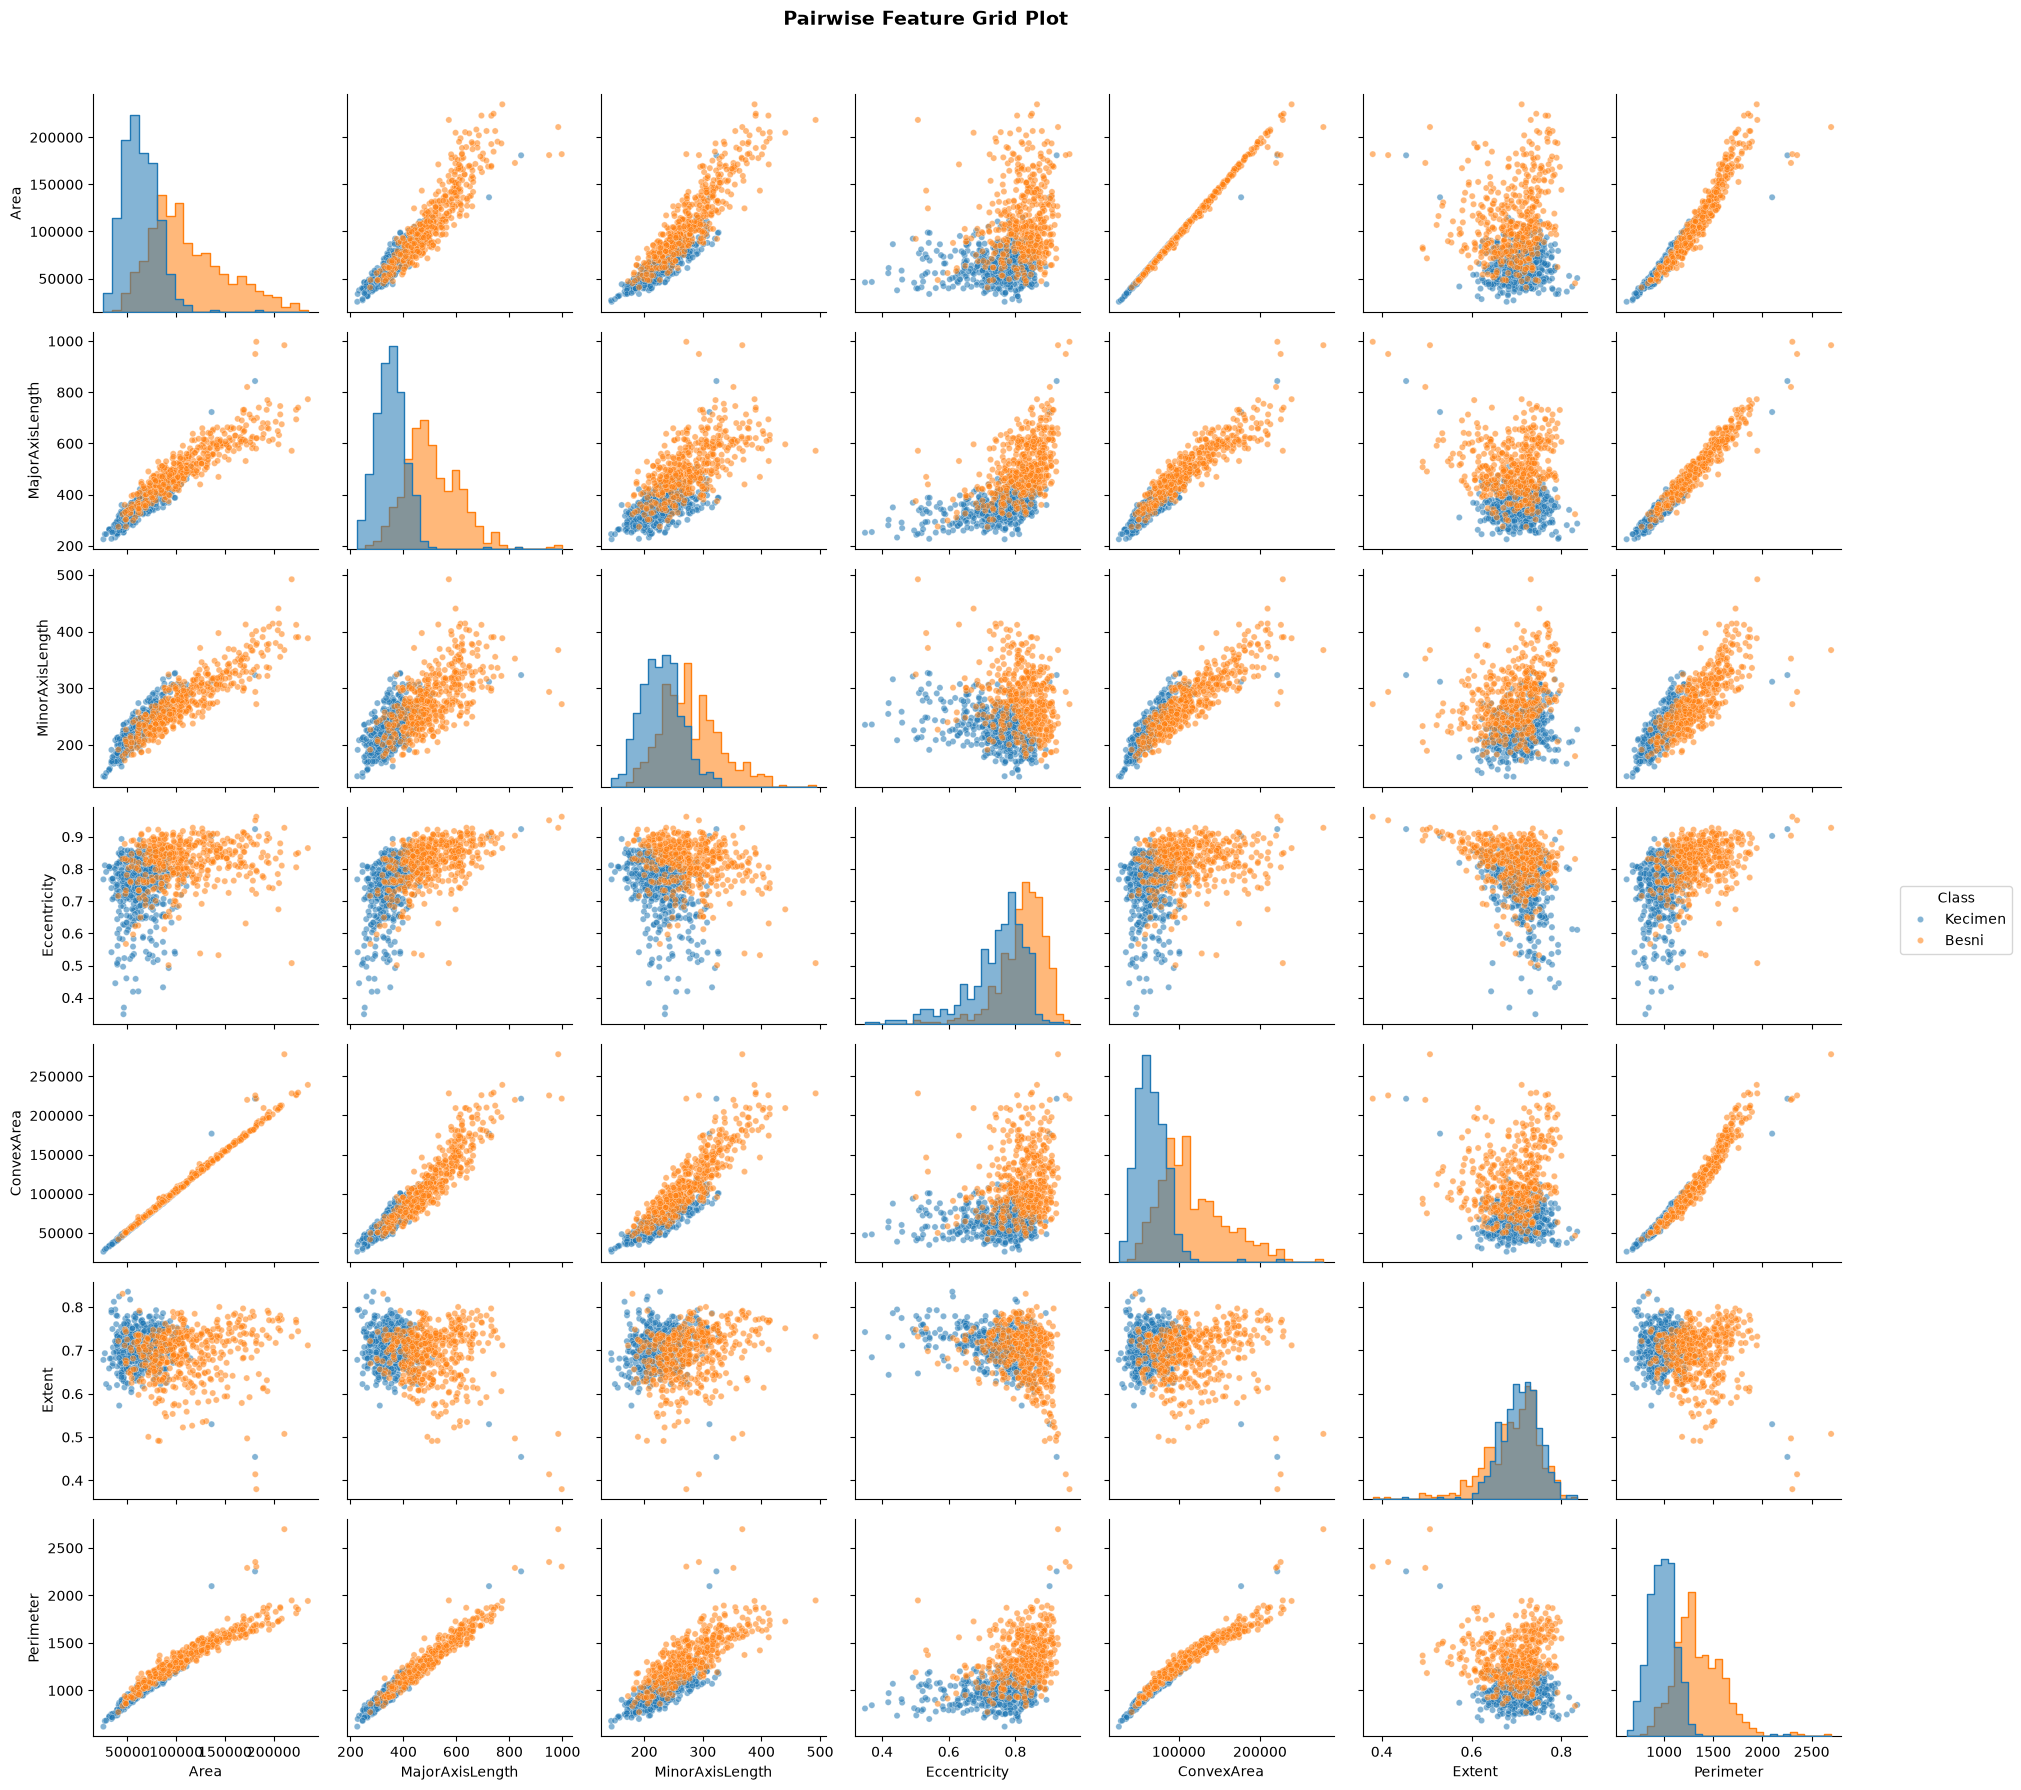

In [ ]:
import numpy as np


# 1. 데이터셋 원본 그대로 로드
raisin = fetch_ucirepo(id=850)
raisin_df = raisin.data.original

# 2. 분석할 피처 리스트와 타겟 컬럼명 지정
raisin_features = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
target_column = 'Class'

# 1) 기본 실행 (자동 수치형 컬럼 선택 및 히스토그램)
plot_pair_grid(df=raisin_df, target='Class')

# 2) 특정 특성만 지정 + 대각선에 밀도 추정(KDE) 적용
# plot_pair_grid(df=raisin_df, features=raisin_features, target='Class', diag_kind='kde')